# Forecasting Models — Casual-Dining Restaurant Daily Sales

⚠️ **All data in this notebook is SIMULATED.** It was generated by `src/simulate_restaurant_sales.py`
to mimic order-of-magnitude sales patterns recalled from personal experience working in casual
dining (day-of-week effects, seasonality, weather sensitivity, promo days). No real point-of-sale,
financial, or transaction data is used anywhere in this project, and the restaurant is intentionally
unnamed — referred to only as "a casual-dining restaurant."

Three approaches are compared on a **time-based holdout** (no shuffling, since this is sequential daily data): **SARIMA** (classical, weekly-seasonal statistical model), **XGBoost** (gradient-boosted trees on engineered time-series features), and **Ridge regression** (linear model on the same engineered features, plus explicit Fourier seasonality terms — a linear model needs seasonality encoded directly, since it can't infer it from splits the way a tree can).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

df = pd.read_csv('../data/daily_sales.csv', parse_dates=['date']).set_index('date').asfreq('D')
df.shape

(940, 18)

## Cleaning for modeling

Closures (Dec 25) are a known true zero, not missing data, so they're set explicitly. Simulated POS-outage gaps and partial-field gaps are interpolated — acceptable for a handful of isolated days, but flagged here rather than silently done.

In [2]:
n_missing_before = df['sales'].isna().sum()
df['sales_clean'] = df['sales']
df.loc[df['is_closed'] == True, 'sales_clean'] = 0
df['sales_clean'] = df['sales_clean'].interpolate(limit_direction='both')
print(f'Interpolated {n_missing_before} missing sales values (POS-outage days); '
      f'{int(df["is_closed"].sum())} closures set to 0.')

Interpolated 7 missing sales values (POS-outage days); 3 closures set to 0.


## Feature engineering (for XGBoost)

Lag and rolling-mean features, plus calendar/weather/event flags already present in the simulated dataset.

In [3]:
model_df = df[['sales_clean','is_weekend','is_special_day','month','weather']].copy()
model_df = model_df.rename(columns={'sales_clean': 'sales'})

for lag in [1, 7, 14, 28]:
    model_df[f'lag_{lag}'] = model_df['sales'].shift(lag)
model_df['roll_mean_7'] = model_df['sales'].shift(1).rolling(7).mean()
model_df['roll_mean_28'] = model_df['sales'].shift(1).rolling(28).mean()
model_df['dow'] = model_df.index.dayofweek
model_df = pd.get_dummies(model_df, columns=['weather'], drop_first=True)
model_df = model_df.dropna()
model_df.shape

(912, 14)

## Time-based train/test split

Last 90 days held out as the test period — no shuffling, so the split respects the sequential nature of the data.

In [4]:
split_date = model_df.index.max() - pd.Timedelta(days=90)
train = model_df[model_df.index <= split_date]
test = model_df[model_df.index > split_date]

print('Train:', train.index.min().date(), '->', train.index.max().date(), f'({len(train)} days)')
print('Test: ', test.index.min().date(), '->', test.index.max().date(), f'({len(test)} days)')

Train: 2024-01-20 -> 2026-04-20 (822 days)
Test:  2026-04-21 -> 2026-07-19 (90 days)


## Model 1: SARIMA

Order `(1,1,1)` with weekly seasonal order `(1,1,1,7)` — captures the dominant day-of-week cycle. A full annual seasonal term (period=365) is computationally impractical for a state-space SARIMA on daily data, so the slower seasonal cycle is a known blind spot for this model, discussed below.

In [5]:
sarima_train = df.loc[train.index, 'sales_clean']
sarima_test = df.loc[test.index, 'sales_clean']

sarima_model = SARIMAX(
    sarima_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False, enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.get_forecast(steps=len(sarima_test)).predicted_mean
sarima_pred.index = sarima_test.index
sarima_pred.head()

date
2026-04-21     4269.874607
2026-04-22     4457.993740
2026-04-23     4813.936532
2026-04-24     4913.810653
2026-04-25    10241.642139
Freq: D, Name: predicted_mean, dtype: float64

## Model 2: XGBoost (lag features)

In [6]:
feature_cols = [c for c in train.columns if c != 'sales']
X_train, y_train = train[feature_cols], train['sales']
X_test, y_test = test[feature_cols], test['sales']

xgb_model = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
xgb_model.fit(X_train, y_train)
xgb_pred = pd.Series(xgb_model.predict(X_test), index=X_test.index)
xgb_pred.head()

date
2026-04-21     5203.147949
2026-04-22     5280.154785
2026-04-23     5105.761719
2026-04-24     4720.835938
2026-04-25    11057.864258
Freq: D, dtype: float32

## Model 3: Ridge regression (linear, engineered features)

Reuses the same lag/rolling/calendar/weather features as XGBoost, but replaces the raw `month`/`dow` integers with explicit Fourier terms (weekly + annual) since a linear model can't discover cyclical structure the way tree splits can — it needs sin/cos encodings handed to it directly. Features are standardized before fitting.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def fourier_terms(index, period, order, prefix):
    t = index.dayofyear if period > 30 else index.dayofweek
    feats = {}
    for k in range(1, order + 1):
        feats[f'{prefix}_sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        feats[f'{prefix}_cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(feats, index=index)

ridge_features = model_df.drop(columns=['sales', 'month', 'dow']).copy()
ridge_features = ridge_features.join(fourier_terms(model_df.index, 365.25, order=3, prefix='doy'))
ridge_features = ridge_features.join(fourier_terms(model_df.index, 7, order=3, prefix='dow'))

X_train_ridge = ridge_features.loc[train.index]
X_test_ridge = ridge_features.loc[test.index]

ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=5.0, random_state=42))
ridge_model.fit(X_train_ridge, y_train)
ridge_pred = pd.Series(ridge_model.predict(X_test_ridge), index=X_test_ridge.index)
ridge_pred.head()

date
2026-04-21     5610.151169
2026-04-22     5445.045572
2026-04-23     5114.324181
2026-04-24     4702.272122
2026-04-25    10733.117648
Freq: D, dtype: float64

## Evaluation on holdout

In [8]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'{name:10s}  MAE=${mae:,.0f}   MAPE={mape:.1%}')
    return mae, mape

sarima_mae, sarima_mape = evaluate(sarima_test, sarima_pred, 'SARIMA')
xgb_mae, xgb_mape = evaluate(y_test, xgb_pred, 'XGBoost')
ridge_mae, ridge_mape = evaluate(y_test, ridge_pred, 'Ridge')

results = pd.DataFrame({
    'Model': ['SARIMA', 'XGBoost', 'Ridge'],
    'MAE ($)': [round(sarima_mae), round(xgb_mae), round(ridge_mae)],
    'MAPE': [f'{sarima_mape:.1%}', f'{xgb_mape:.1%}', f'{ridge_mape:.1%}'],
}).set_index('Model')
results

SARIMA      MAE=$1,445   MAPE=14.4%
XGBoost     MAE=$959   MAPE=11.7%
Ridge       MAE=$1,012   MAPE=12.4%


,MAE ($),MAPE
Model,,
SARIMA,1445,14.4%
XGBoost,959,11.7%
Ridge,1012,12.4%


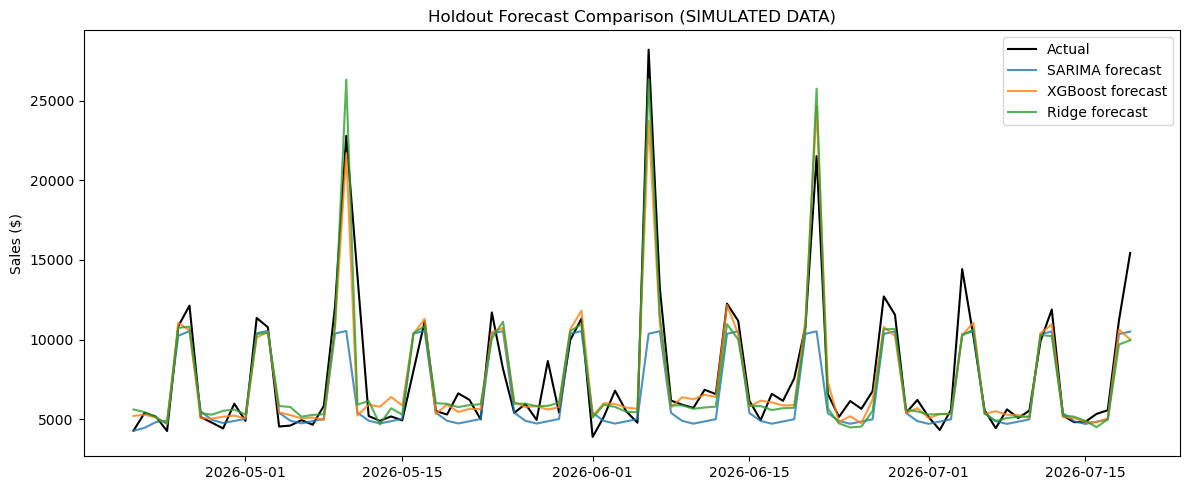

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(sarima_test.index, sarima_test.values, label='Actual', color='black', linewidth=1.5)
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA forecast', alpha=0.8)
plt.plot(xgb_pred.index, xgb_pred.values, label='XGBoost forecast', alpha=0.8)
plt.plot(ridge_pred.index, ridge_pred.values, label='Ridge forecast', alpha=0.8)
plt.title('Holdout Forecast Comparison (SIMULATED DATA)')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

| Model | MAE | MAPE |
|---|---|---|
| SARIMA (weekly-seasonal) | $1,445 | 14.4% |
| **XGBoost** (lag/rolling features) | **$959** | **11.7%** |
| Ridge (linear, Fourier + lag features) | $1,012 | 12.4% |

**XGBoost wins**, but only narrowly over Ridge (~6% lower MAE) — both comfortably beat SARIMA
by 30%+. That gap between XGBoost and Ridge is the more interesting result: once seasonality is
handed to a linear model explicitly as Fourier terms (rather than left for the model to infer),
a plain regularized linear model gets most of the way to tree-based performance on this dataset.
The remaining edge for XGBoost likely comes from its ability to model interactions XGBoost gets
for free from splits but Ridge would need explicit interaction terms for — e.g. weather effects
compounding differently on weekends vs weekdays, or special-day spikes interacting with season.

SARIMA lags both because its seasonal term only covers the weekly cycle — a full annual
seasonal order (period=365) is computationally impractical for daily-frequency state-space
SARIMA, so it has no direct way to see the October peak, summer trough, or one-off special-day
spikes, only what differencing and trend infer indirectly.

**Caveat:** this comparison is on simulated data with effect sizes the author chose, so the
absolute MAE/MAPE numbers are illustrative of methodology, not a claim about real-world
forecast accuracy for any actual restaurant.
